# 📈 Chương 3 — Dataset 1: Stock Market Sentiment — Vanilla RNN
## Kỹ thuật: Tokenization + Word Embedding + Vanilla RNN

**Pipeline:** EDA → WordCloud → Tokenize → Embedding → RNN → Train → Evaluate

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import re, os, warnings

import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

DATA_DIR = '../data/stock_sentiment'
SAVE_DIR = '../results/stock_sentiment'
os.makedirs(SAVE_DIR, exist_ok=True)

VOCAB_SIZE  = 10000
MAX_LEN     = 50
EMBED_DIM   = 64
EPOCHS      = 10
BATCH_SIZE  = 64

print(f'TF: {tf.__version__}')

2026-05-09 19:58:00.241951: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 19:58:00.272130: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 19:58:00.724105: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TF: 2.13.0


## 📂 1. Load & Explore Data

In [2]:
# Load CSV — try common filenames
import glob
csv_files = glob.glob(f'{DATA_DIR}/**/*.csv', recursive=True) + glob.glob(f'{DATA_DIR}/*.csv')
print('Found CSV files:', csv_files)
df = pd.read_csv(csv_files[0])
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Found CSV files: ['../data/stock_sentiment/stock_data.csv', '../data/stock_sentiment/stock_data.csv']
Shape: (5791, 2)
Columns: ['Text', 'Sentiment']


,Text,Sentiment
0,Kickers on my watchlist XIDE TIT SOQ PNK CPW B...,1
1,user: AAP MOVIE. 55% return for the FEA/GEED i...,1
2,user I'd be afraid to short AMZN - they are lo...,1
3,MNTA Over 12.00,1
4,OI Over 21.37,1


In [3]:
# Identify text and label columns
# Common patterns: 'text'/'headline'/'sentence' and 'sentiment'/'label'
text_col  = [c for c in df.columns if any(k in c.lower() for k in ['text','headline','sentence','news'])][0]
label_col = [c for c in df.columns if any(k in c.lower() for k in ['sentiment','label','class'])][0]
print(f'Text column  : {text_col}')
print(f'Label column : {label_col}')
print(f'Label distribution:\n{df[label_col].value_counts()}')

Text column  : Text
Label column : Sentiment
Label distribution:
Sentiment
 1    3685
-1    2106
Name: count, dtype: int64


In [4]:
# Drop nulls and rename
df = df[[text_col, label_col]].dropna()
df.columns = ['text', 'label']

# Normalize labels to 0/1 if needed
if df['label'].dtype == object:
    label_map = {v: i for i, v in enumerate(sorted(df['label'].unique()))}
    df['label'] = df['label'].map(label_map)
    print('Label mapping:', label_map)

print(f'Final shape: {df.shape}')
print(df['label'].value_counts())

Final shape: (5791, 2)
label
 1    3685
-1    2106
Name: count, dtype: int64


## 📊 2. EDA — Phân tích văn bản

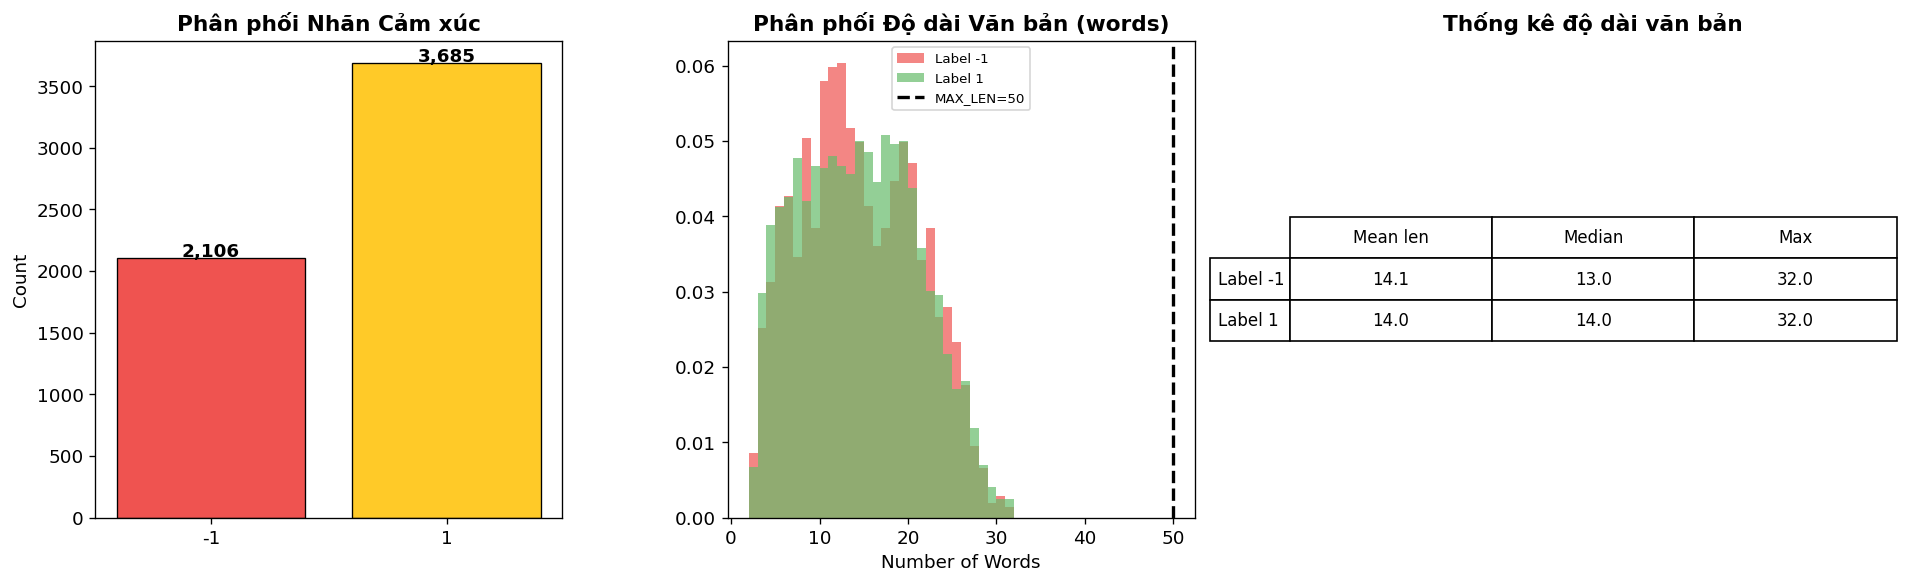

In [5]:
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Label distribution
label_names = [str(v) for v in sorted(df['label'].unique())]
counts = df['label'].value_counts().sort_index()
bars = axes[0].bar(label_names, counts.values,
                   color=['#EF5350','#FFCA28','#66BB6A'][:len(label_names)],
                   edgecolor='black', linewidth=0.8)
axes[0].set_title('Phân phối Nhãn Cảm xúc')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{val:,}', ha='center', fontweight='bold')

# Text length distribution
for lbl, color in zip(sorted(df['label'].unique()), ['#EF5350','#66BB6A','#42A5F5']):
    axes[1].hist(df[df['label']==lbl]['text_len'], bins=30, alpha=0.7,
                 color=color, label=f'Label {lbl}', density=True)
axes[1].axvline(MAX_LEN, color='black', linestyle='--', lw=2, label=f'MAX_LEN={MAX_LEN}')
axes[1].set_title('Phân phối Độ dài Văn bản (words)')
axes[1].set_xlabel('Number of Words')
axes[1].legend(fontsize=8)

# Length stats
stats = df.groupby('label')['text_len'].describe()[['mean','50%','max']]
axes[2].axis('off')
table = axes[2].table(cellText=stats.round(1).values,
                      rowLabels=[f'Label {i}' for i in stats.index],
                      colLabels=['Mean len', 'Median', 'Max'],
                      loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 2)
axes[2].set_title('Thống kê độ dài văn bản')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_label_textlen_dist.png', bbox_inches='tight')
plt.show()

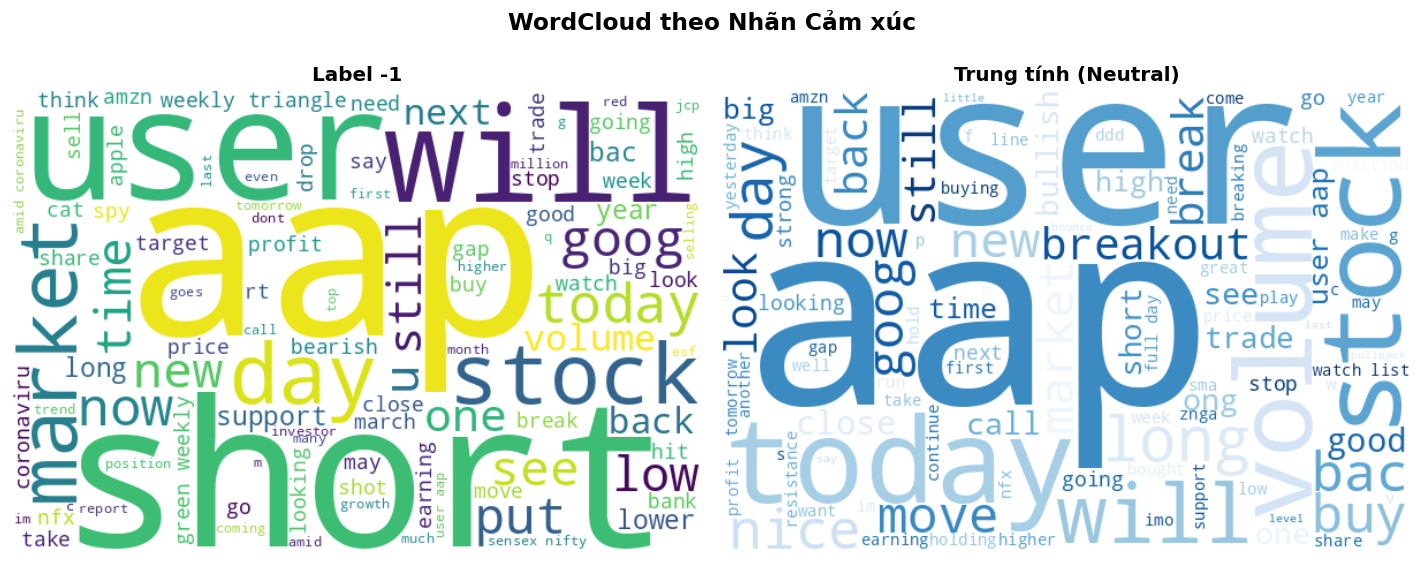

In [6]:
# WordCloud per label
unique_labels = sorted(df['label'].unique())
label_titles  = {0: 'Tiêu Cực (Negative)', 1: 'Trung tính (Neutral)', 2: 'Tích Cực (Positive)'}
label_colors  = {0: 'Reds', 1: 'Blues', 2: 'Greens'}

fig, axes = plt.subplots(1, len(unique_labels), figsize=(6*len(unique_labels), 5))
if len(unique_labels) == 1:
    axes = [axes]

for ax, lbl in zip(axes, unique_labels):
    text_corpus = ' '.join(df[df['label']==lbl]['text'].astype(str).tolist())
    # Remove common stopwords manually
    text_corpus = re.sub(r'[^a-zA-Z\s]', '', text_corpus.lower())
    wc = WordCloud(width=600, height=400,
                   max_words=100,
                   colormap=label_colors.get(lbl, 'viridis'),
                   background_color='white').generate(text_corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(label_titles.get(lbl, f'Label {lbl}'), fontsize=12)

plt.suptitle('WordCloud theo Nhãn Cảm xúc', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_wordclouds.png', bbox_inches='tight')
plt.show()

## ⚙️ 3. Preprocessing — Tokenize & Pad

In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

X = df['clean_text'].values
y = df['label'].values
NUM_CLASSES = len(np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

# Tokenize
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Vocab size (actual): {len(tokenizer.word_index):,}')
print(f'Train: {X_train_seq.shape}, Test: {X_test_seq.shape}')
print(f'Num classes: {NUM_CLASSES}')

Vocab size (actual): 8,375
Train: (4632, 50), Test: (1159, 50)
Num classes: 2


In [8]:
# Visualize tokenization
sample_idx = 0
print('=== TOKENIZATION DEMO ===')
print(f'Original  : {X_train[sample_idx]}')
print(f'Cleaned   : {df["clean_text"].iloc[sample_idx]}')
print(f'Token IDs : {X_train_seq[sample_idx][:20]}...')
print(f'Padding   : {(X_train_seq[0] == 0).sum()} zero-padded positions')

# Coverage analysis
oov_rate = (X_train_seq == 1).sum() / X_train_seq.size
print(f'\nOOV rate in train: {oov_rate:.4f}')

=== TOKENIZATION DEMO ===
Original  : tcs share price jumps on no layoffs dividend announcements should you buy sell or hold the stock httpstcoijdfjrdlol
Cleaned   : kickers on my watchlist xide tit soq pnk cpw bpz aj trade method or method see prev posts
Token IDs : [2554  226  104  862    5   74 3637  448 1985  105   44   59  154   79
  189    2   42 3638    0    0]...
Padding   : 32 zero-padded positions

OOV rate in train: 0.0000


## 🏗️ 4. Xây dựng Vanilla RNN Model

In [9]:
if NUM_CLASSES == 2:
    output_units, loss_fn, activation = 1, 'binary_crossentropy', 'sigmoid'
else:
    output_units, loss_fn, activation = NUM_CLASSES, 'sparse_categorical_crossentropy', 'softmax'

model = models.Sequential([
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, name='embedding'),
    layers.SimpleRNN(64, return_sequences=True, name='rnn_1'),
    layers.Dropout(0.3),
    layers.SimpleRNN(32, name='rnn_2'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu', name='dense_hidden'),
    layers.Dense(output_units, activation=activation, name='output')
], name='VanillaRNN_StockSentiment')

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=loss_fn,
              metrics=['accuracy'])
model.summary()

Model: "VanillaRNN_StockSentiment"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 50, 64)            640000    
                                                                 
 rnn_1 (SimpleRNN)           (None, 50, 64)            8256      
                                                                 
 dropout (Dropout)           (None, 50, 64)            0         
                                                                 
 rnn_2 (SimpleRNN)           (None, 32)                3104      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_hidden (Dense)        (None, 32)                1056      
                                                                 
 output (Dense)              (None, 1)   

2026-05-09 19:58:02.660578: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-09 19:58:02.661682: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-09 19:58:02.662828: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

## 🚀 5. Training

In [10]:
history = model.fit(
    X_train_seq, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy'),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
    ],
    verbose=1
)

Epoch 1/10
62/62 [==============================] - 2s 15ms/step - loss: 0.6095 - accuracy: 0.0691 - val_loss: 0.5171 - val_accuracy: 0.1180 - lr: 0.0010
Epoch 2/10
62/62 [==============================] - 1s 10ms/step - loss: 0.1764 - accuracy: 0.3078 - val_loss: 0.2764 - val_accuracy: 0.2820 - lr: 0.0010
Epoch 3/10
62/62 [==============================] - 1s 11ms/step - loss: -1.6329 - accuracy: 0.4295 - val_loss: 0.3345 - val_accuracy: 0.3597 - lr: 0.0010
Epoch 4/10
62/62 [==============================] - 1s 10ms/step - loss: -6.9255 - accuracy: 0.5047 - val_loss: -1.0561 - val_accuracy: 0.4806 - lr: 0.0010
Epoch 5/10
62/62 [==============================] - 1s 11ms/step - loss: -16.9189 - accuracy: 0.5316 - val_loss: -3.3809 - val_accuracy: 0.4719 - lr: 0.0010
Epoch 6/10
62/62 [==============================] - 1s 10ms/step - loss: -20.6807 - accuracy: 0.5174 - val_loss: -5.6759 - val_accuracy: 0.5209 - lr: 0.0010
Epoch 7/10
62/62 [==============================] - 1s 9ms/step - l

## 📈 6. Phân tích Kết quả

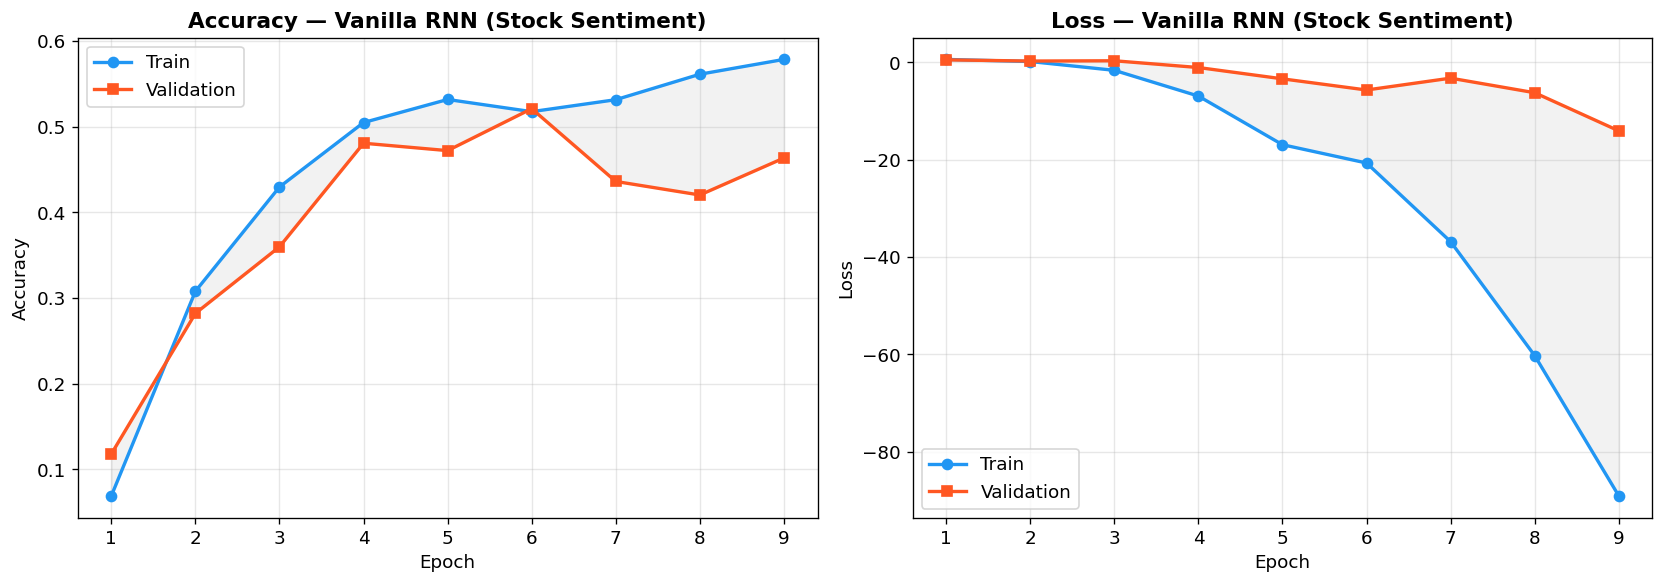

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eps = range(1, len(history.history['accuracy'])+1)

for ax, (tr, vl, metric) in zip(axes, [
    ('accuracy', 'val_accuracy', 'Accuracy'),
    ('loss',     'val_loss',     'Loss')
]):
    ax.plot(eps, history.history[tr], 'o-', color='#2196F3', lw=2, label='Train')
    ax.plot(eps, history.history[vl], 's-', color='#FF5722', lw=2, label='Validation')
    ax.fill_between(eps, history.history[tr], history.history[vl], alpha=0.1, color='gray')
    ax.set_title(f'{metric} — Vanilla RNN (Stock Sentiment)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_training_history.png', bbox_inches='tight')
plt.show()

              precision    recall  f1-score   support

     Class 0       0.58      0.41      0.48       421
     Class 1       0.71      0.83      0.77       738

    accuracy                           0.68      1159
   macro avg       0.65      0.62      0.63      1159
weighted avg       0.67      0.68      0.66      1159



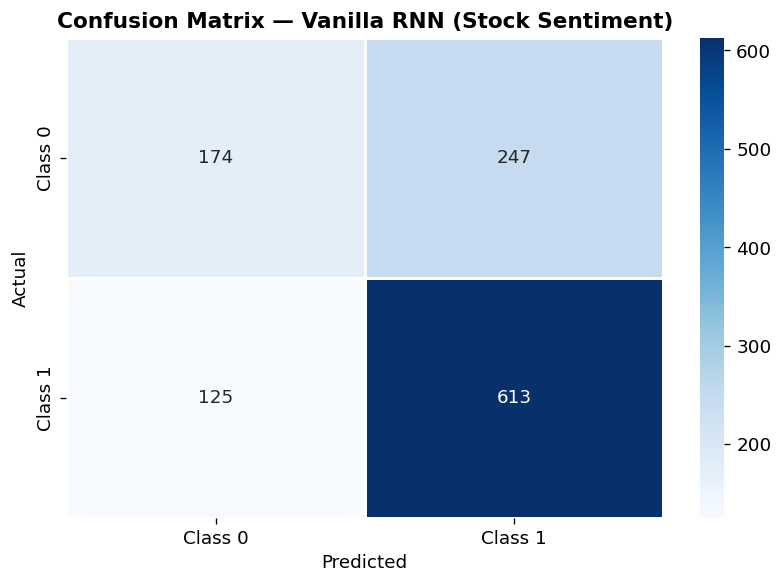

In [15]:
# Evaluation
y_pred_raw = model.predict(X_test_seq, verbose=0)
if NUM_CLASSES == 2:
    y_pred = np.where(y_pred_raw.flatten() >= 0.5, 1, -1)
else:
    y_pred = np.argmax(y_pred_raw, axis=1)

target_names = [f'Class {i}' for i in range(NUM_CLASSES)]
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.8, ax=ax)
ax.set_title('Confusion Matrix — Vanilla RNN (Stock Sentiment)')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_confusion_matrix.png', bbox_inches='tight')
plt.show()

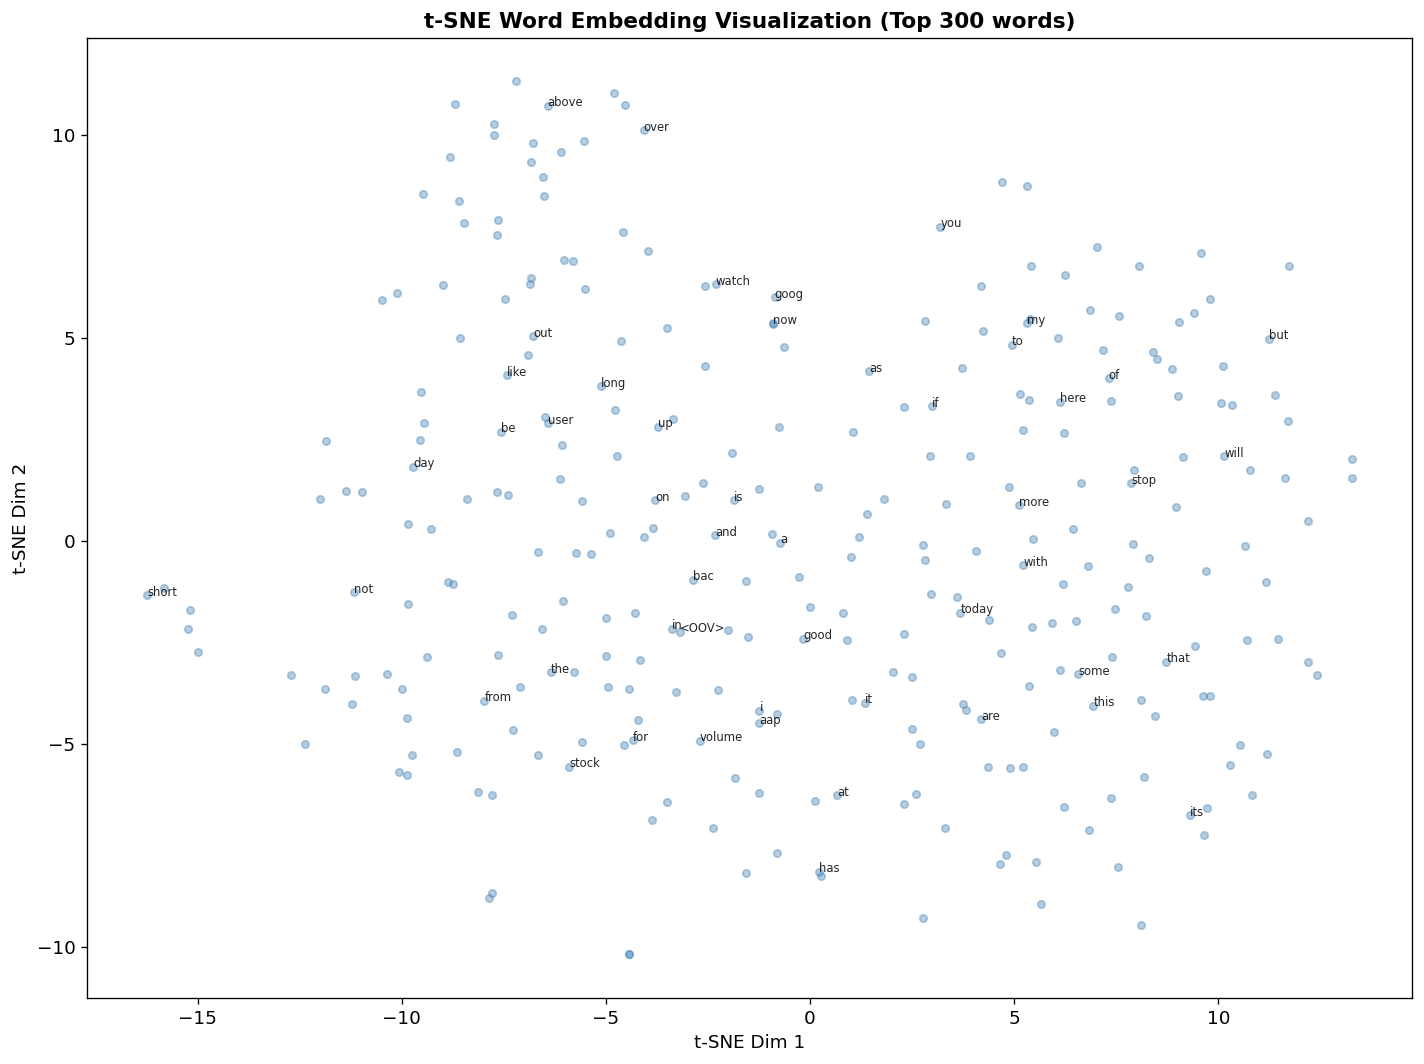

In [17]:
from sklearn.manifold import TSNE

embedding_weights=model.get_layer('embedding').get_weights()[0]

top_n=300
top_words=list(tokenizer.word_index.keys())[:top_n]
top_vecs=embedding_weights[1:top_n+1]

tsne=TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=30,
    max_iter=500
)

reduced=tsne.fit_transform(top_vecs)

plt.figure(figsize=(12,9))
plt.scatter(reduced[:,0],reduced[:,1],alpha=.4,s=20,color='steelblue')

for i,w in enumerate(top_words[:50]):
    plt.annotate(w,(reduced[i,0],reduced[i,1]),fontsize=7,alpha=.85)

plt.title('t-SNE Word Embedding Visualization (Top 300 words)',fontweight='bold')
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_embedding_tsne.png',dpi=300,bbox_inches='tight')
plt.show()

In [18]:
best_val_acc = max(history.history['val_accuracy'])
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('Stock Sentiment — Vanilla RNN\n' + '='*50 + '\n')
    f.write(f'Best Val Accuracy: {best_val_acc:.4f}\n')
    f.write(f'Total Params: {model.count_params():,}\n\n')
    f.write(classification_report(y_test, y_pred, target_names=target_names))

print('✅ Stock Sentiment RNN Experiment Done! Saved to', SAVE_DIR)

✅ Stock Sentiment RNN Experiment Done! Saved to ../results/stock_sentiment
